# 02 · Rental EDA — questions, evidence and modeling readiness

This is a descriptive analysis of a fully inspected snapshot, **not** model evaluation on an untouched holdout. Prices are asking rents in the listing sample. Main statistics: median, Q1–Q3 and n. Groups below 10 show coverage only; 10–29 are exploratory; ≥30 support the main comparisons but do not guarantee representativeness.

Questions: sample composition → price/area distributions → district differences → property-feature relationships → stability across sources/filters. No model training or temporal analysis is performed here.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if not (ROOT / "data/processed/listings.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "data/processed/listings.csv").exists():
    raise FileNotFoundError("Open the notebook from the project root or notebooks/")
sys.path.insert(0, str(ROOT))
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)


In [2]:
from src.eda_reporting import (load_analysis, summarize, missing_summary, feature_coverage,
    area_missing_comparison, source_comparison, select_controlled, sensitivity_sets,
    proposed_split_coverage, generate_figures, write_report)
analysis = load_analysis(ROOT)
price = analysis[analysis.include_price].copy()
figures = generate_figures(analysis, ROOT)
def show_figure(number):
    display(Image(filename=str(figures[number-1])))
print(f"Input={len(analysis)}, price set={len(price)}, primary price/m²={analysis.include_ppm2.sum()}")

Input=1970, price set=1846, primary price/m²=1140


## 1. Coverage and missingness

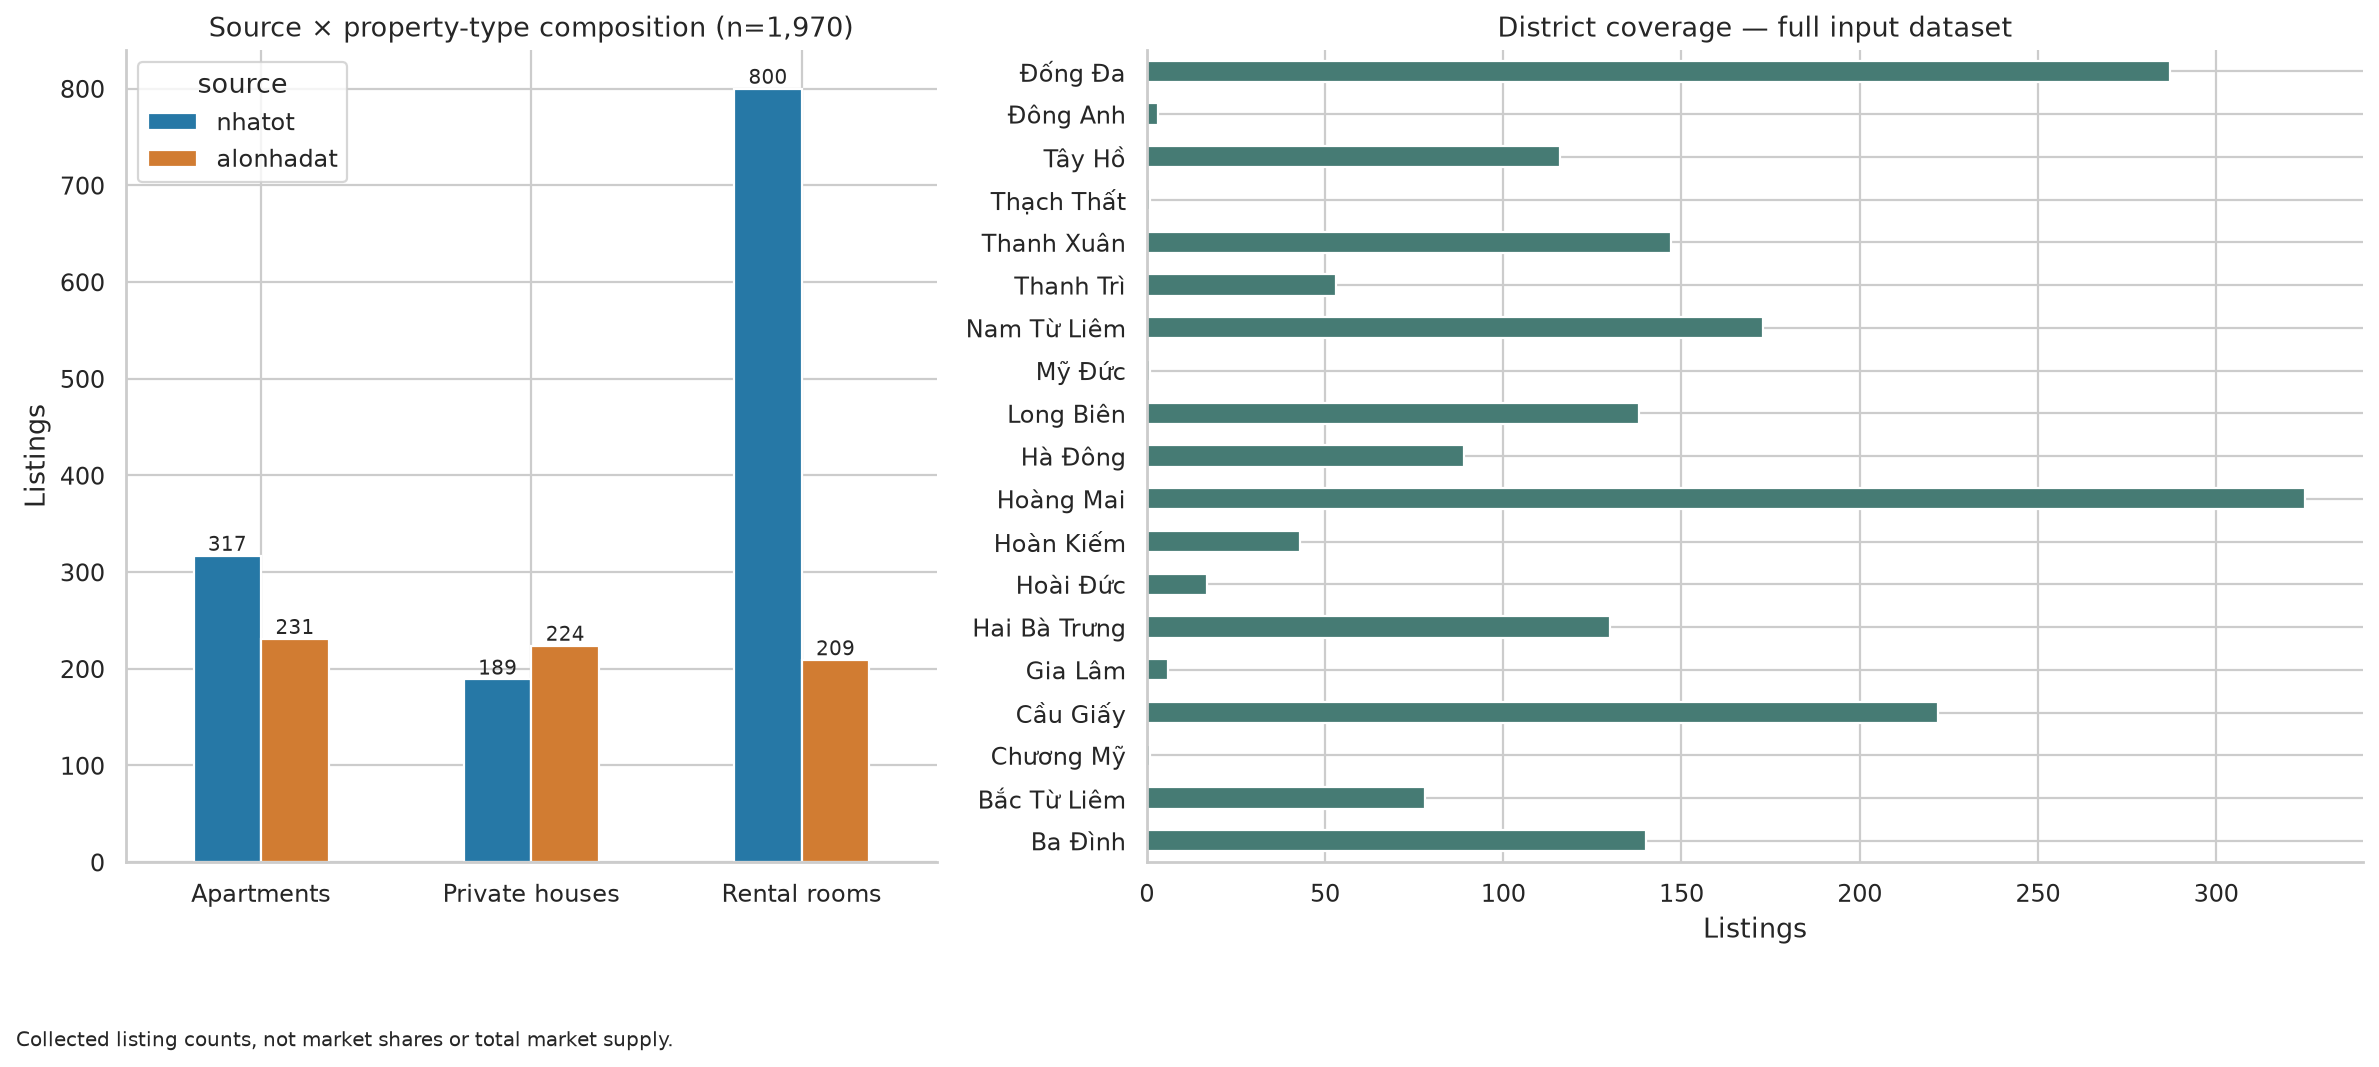

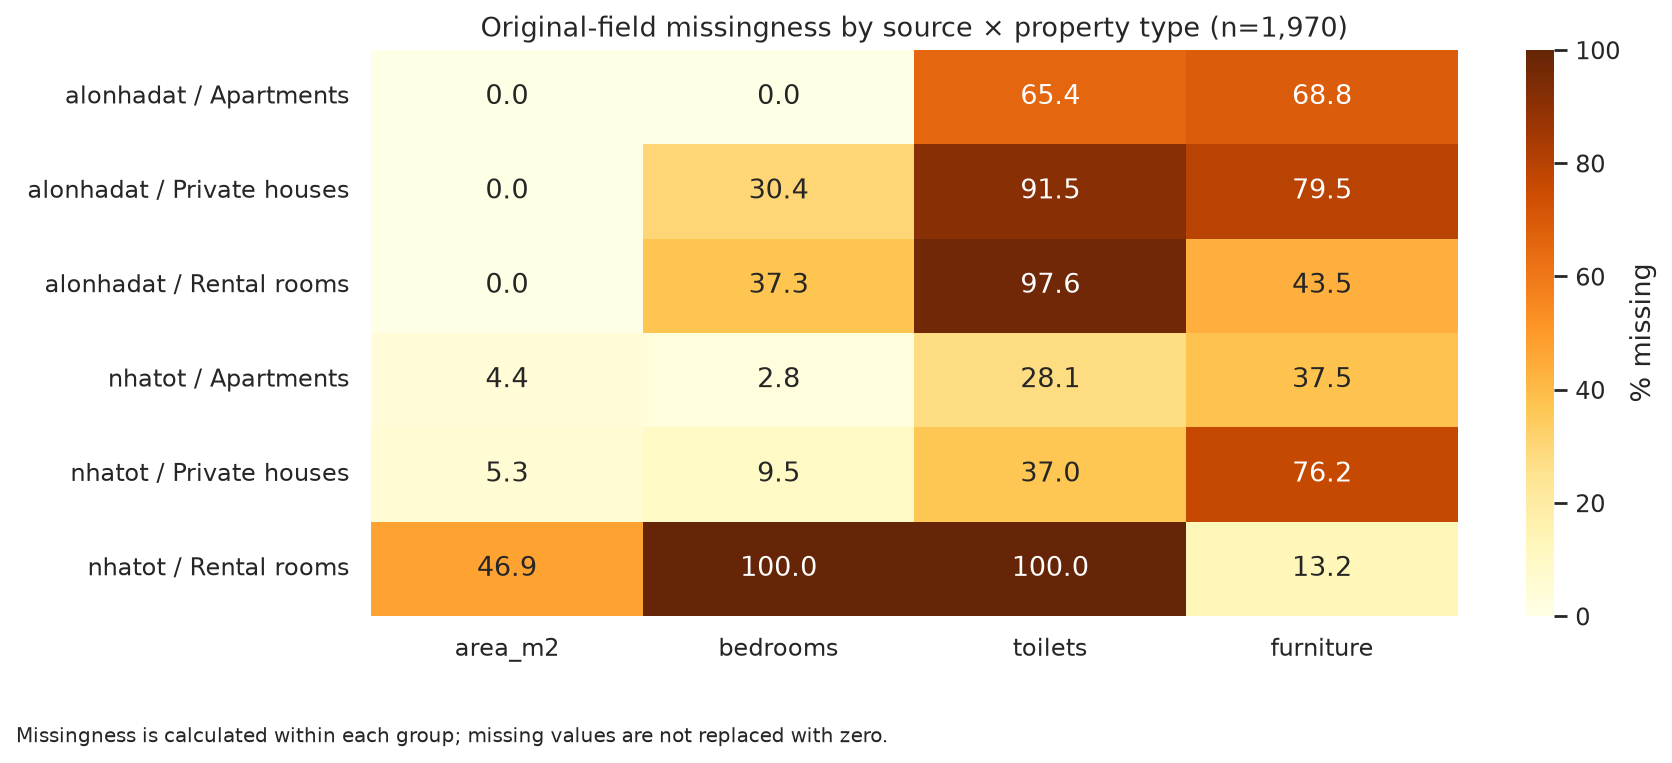

,source,category,area_available,n,median,q1,q3,p90
0,alonhadat,can_ho_chung_cu,True,227,14.00,11.000,17.000,21.40
1,alonhadat,nha_rieng,False,1,552.00,552.000,552.000,552.00
2,alonhadat,nha_rieng,True,138,12.75,8.625,29.250,89.50
3,alonhadat,nha_tro,True,206,4.30,3.000,5.500,7.00
4,nhatot,can_ho_chung_cu,False,14,4.85,3.800,8.300,11.41
5,nhatot,can_ho_chung_cu,True,300,7.10,5.500,10.000,13.00
6,nhatot,nha_rieng,False,10,7.25,6.250,9.125,12.40
7,nhatot,nha_rieng,True,173,11.00,9.000,15.000,18.00
8,nhatot,nha_tro,False,370,4.50,3.700,5.275,6.41
9,nhatot,nha_tro,True,407,3.50,2.500,4.500,5.50


In [3]:
show_figure(1)
show_figure(2)
display(area_missing_comparison(price))

## 2. Price and area distributions by property type

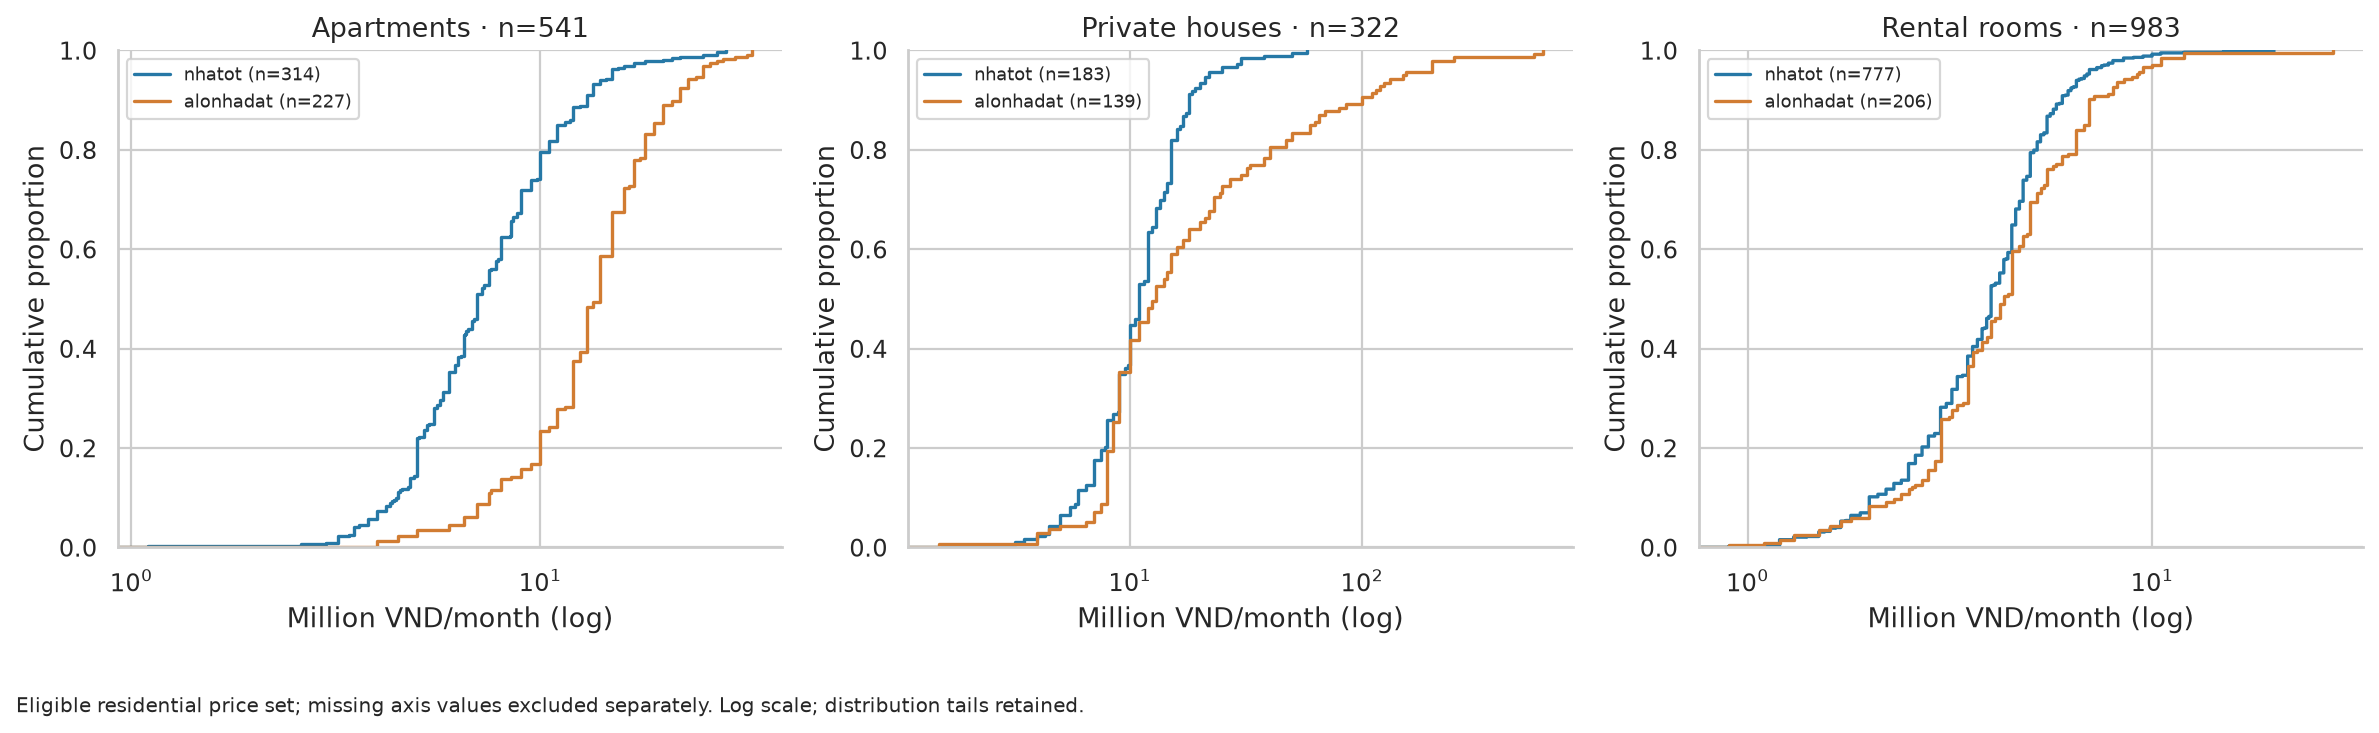

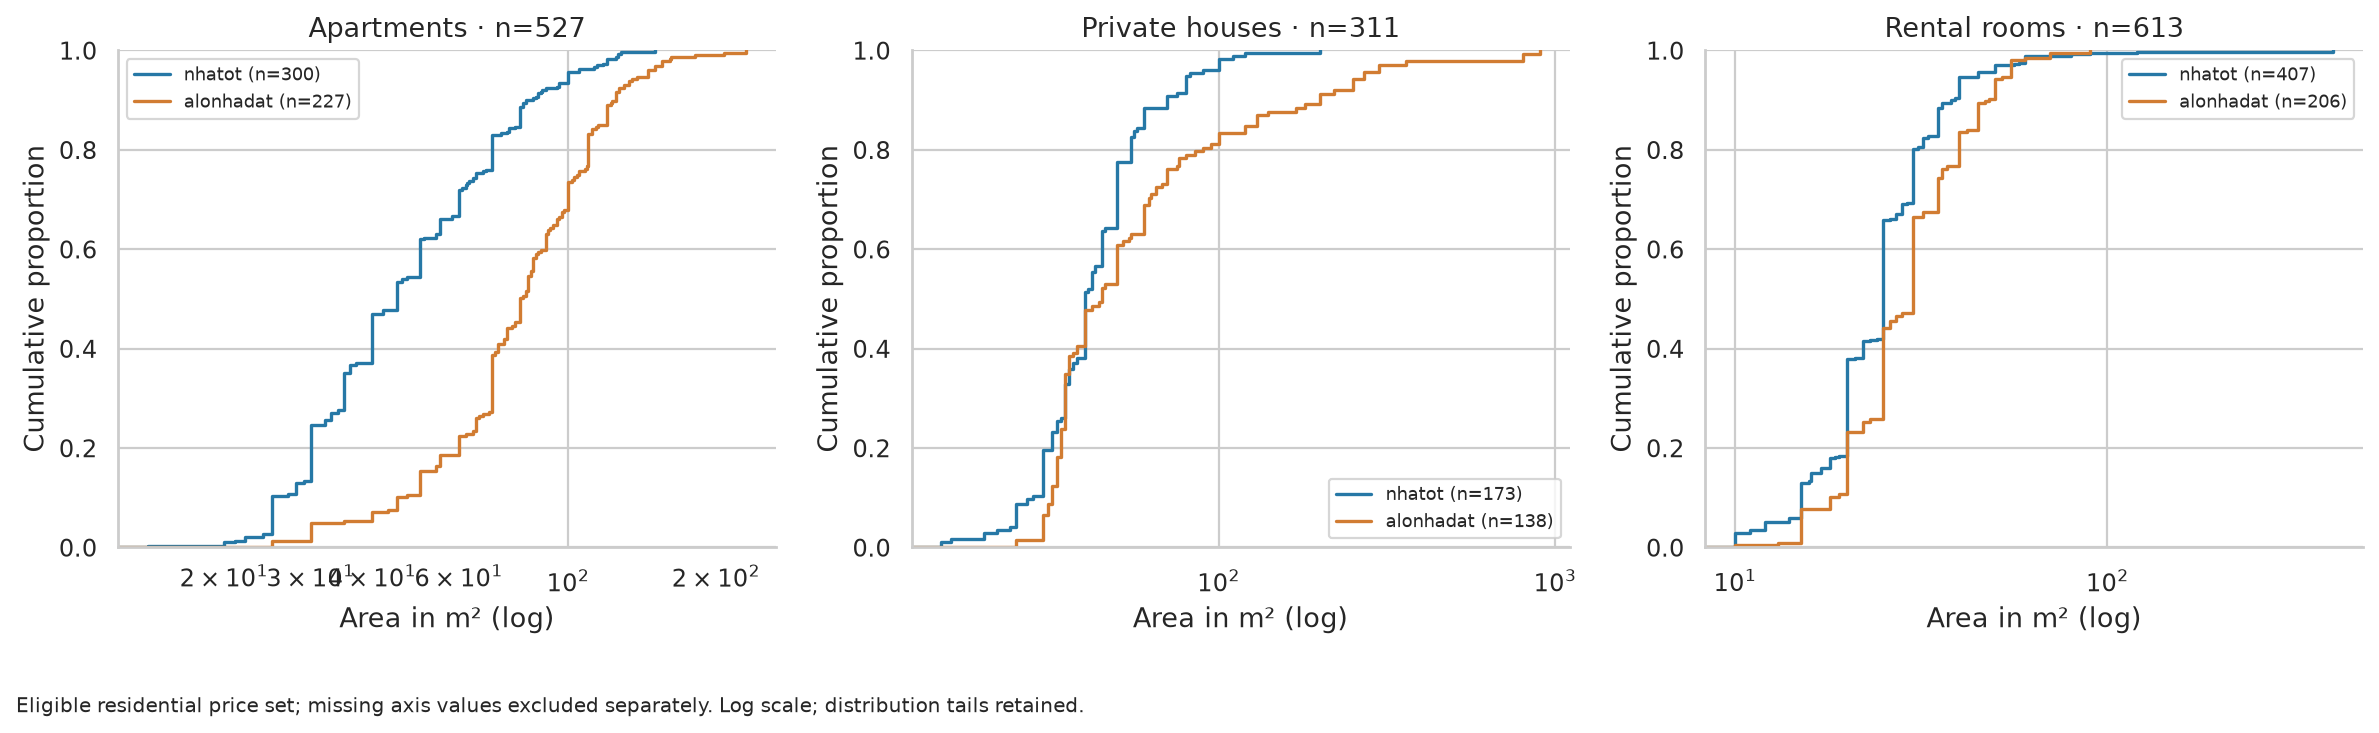

,category,n,median,q1,q3,p90
0,can_ho_chung_cu,541,9.80,6.5,14.0,18.0
1,nha_rieng,322,11.75,8.5,17.0,38.0
2,nha_tro,983,4.00,3.0,5.0,6.5


,category,n,median,q1,q3,p90
0,can_ho_chung_cu,527,60.0,40.0,84.0,110.0
1,nha_rieng,311,41.0,34.5,58.5,100.0
2,nha_tro,613,25.0,20.0,30.0,40.0


In [4]:
show_figure(3)
show_figure(4)
display(summarize(price, ["category"]))
display(summarize(price, ["category"], "area_analysis_m2"))

## 3. District comparisons within property type

Compare relative differences, not market rankings. Q1–Q3 describe dispersion, not confidence intervals. Area/source composition can still vary across districts. Price/m² is secondary and is not used to rank private houses.

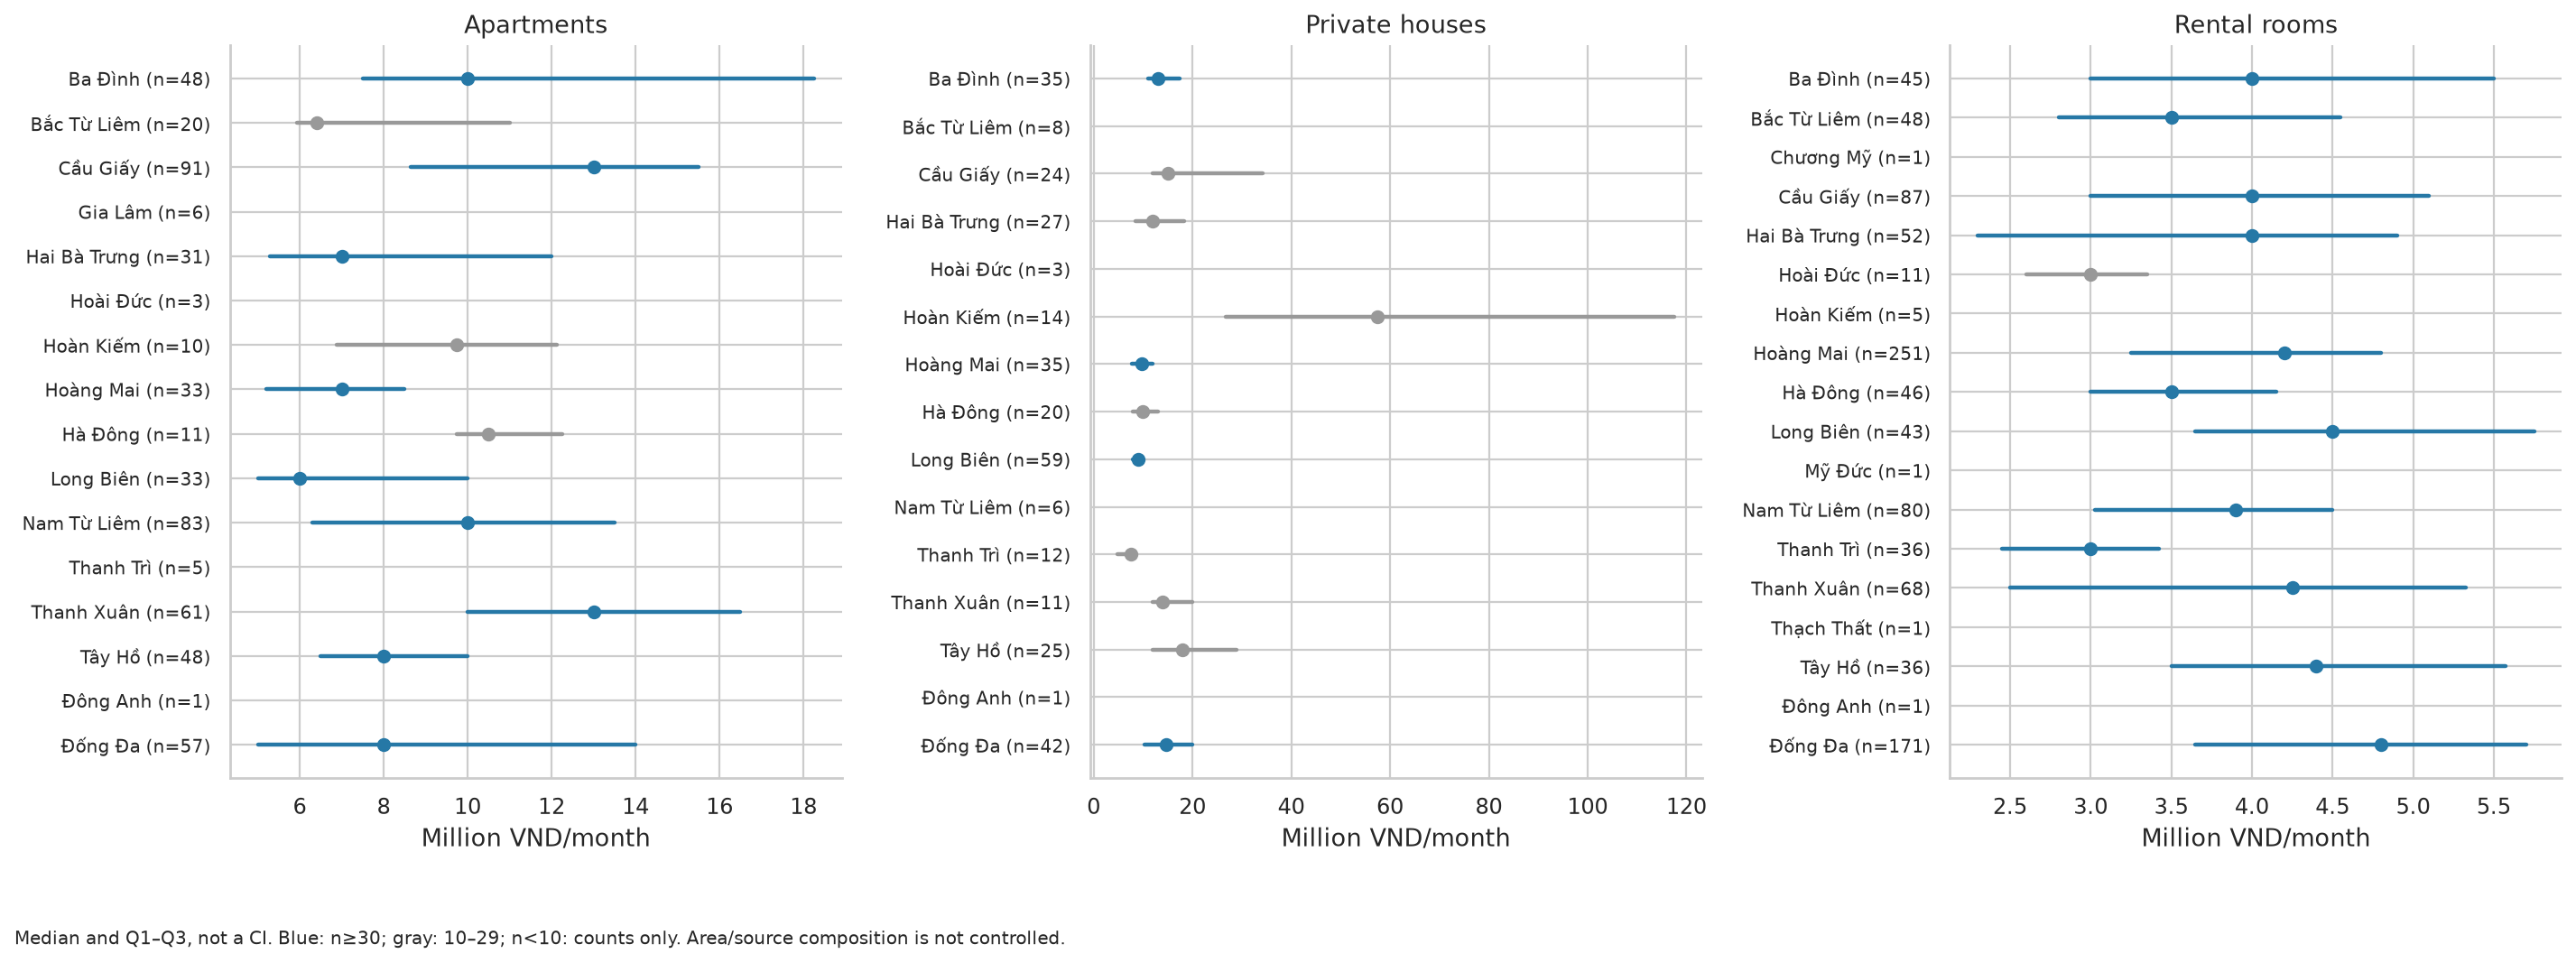

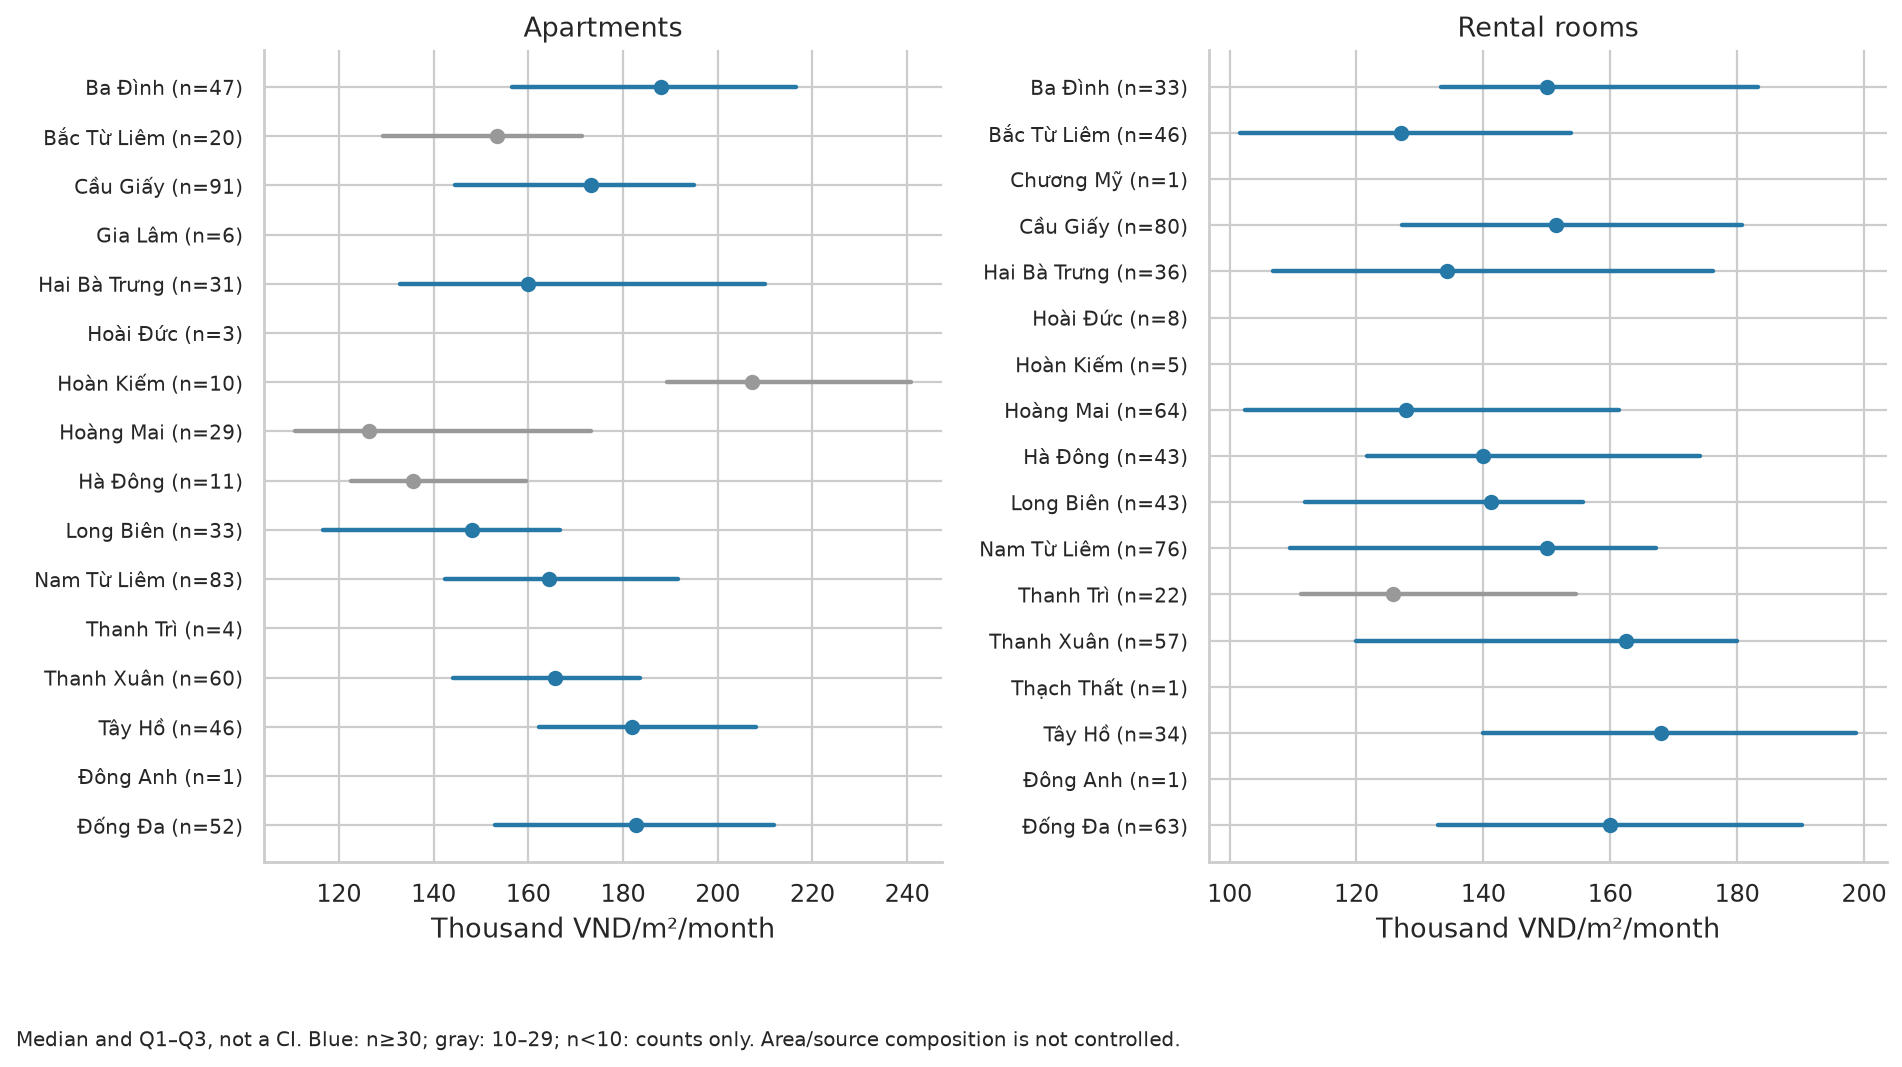

,category,n,median,q1,q3,p90
0,can_ho_chung_cu,527,168421.052632,140000.0,200000.0,221090.909091
1,nha_tro,613,144444.444444,116000.0,175000.0,203636.363636


In [5]:
show_figure(5)
show_figure(6)
display(summarize(analysis[analysis.include_ppm2], ["category"], "price_per_m2"))

## 4. Area, bedrooms and furnishing

Compare bedroom/furnishing groups within comparable strata with ≥10 listings in at least two known levels. If fully matched groups are too small, relax district matching and label the result exploratory. Select strata by n, not price differences. Furnishing comparisons use Nhatot only; missing values remain Unknown.

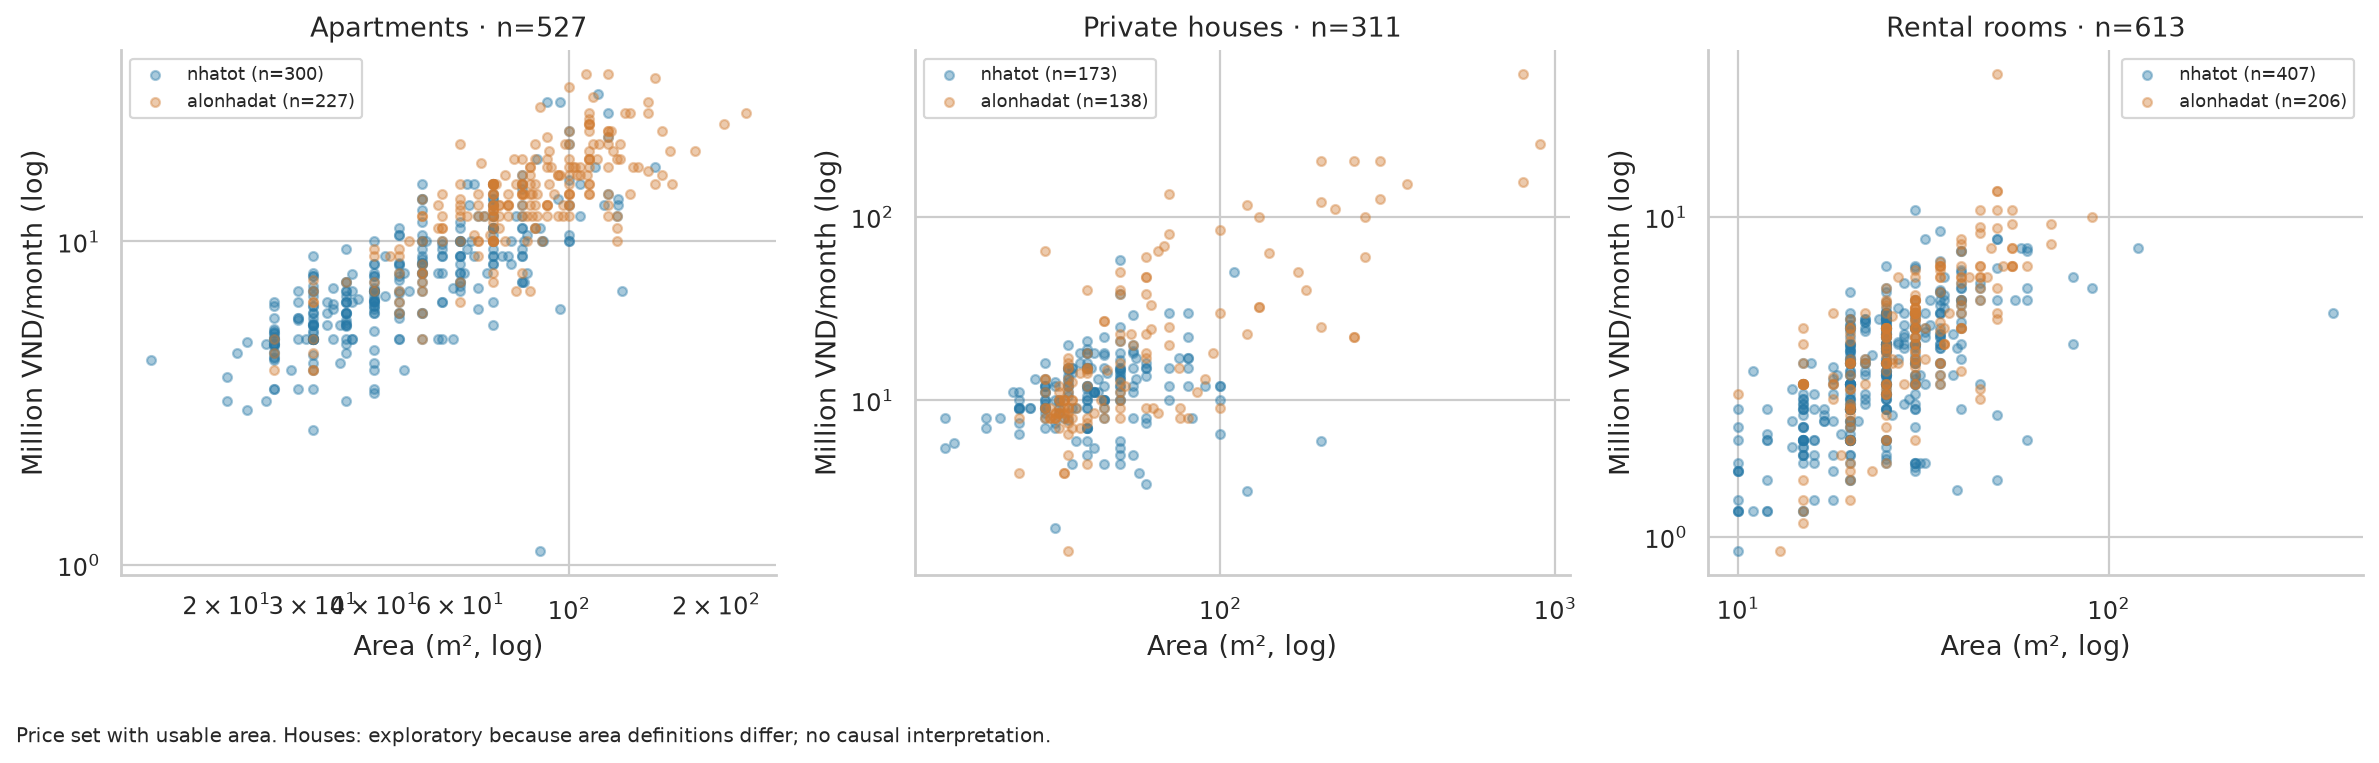

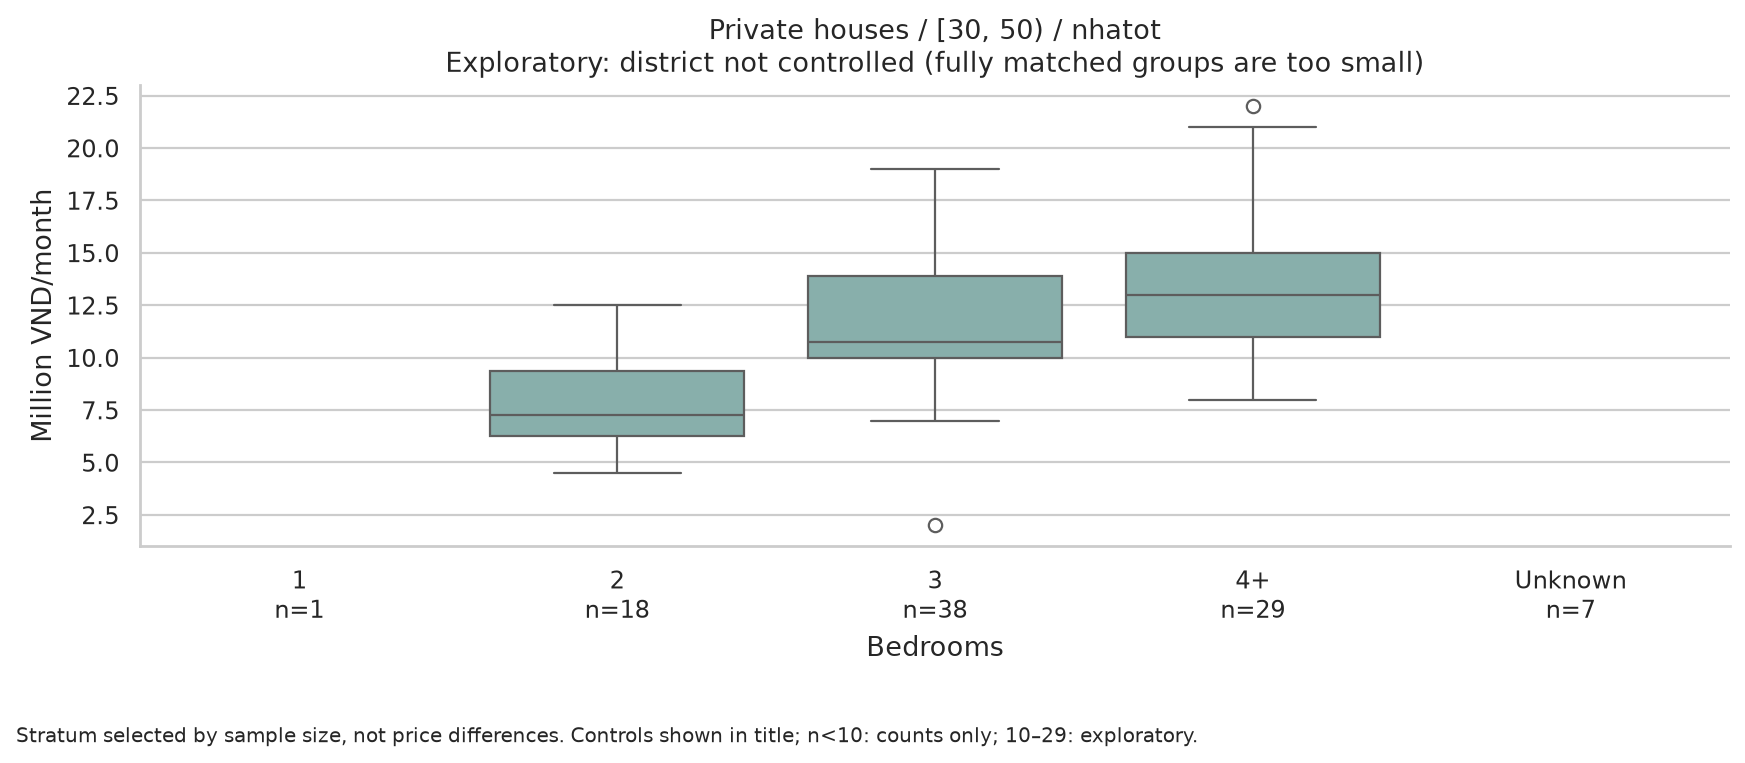

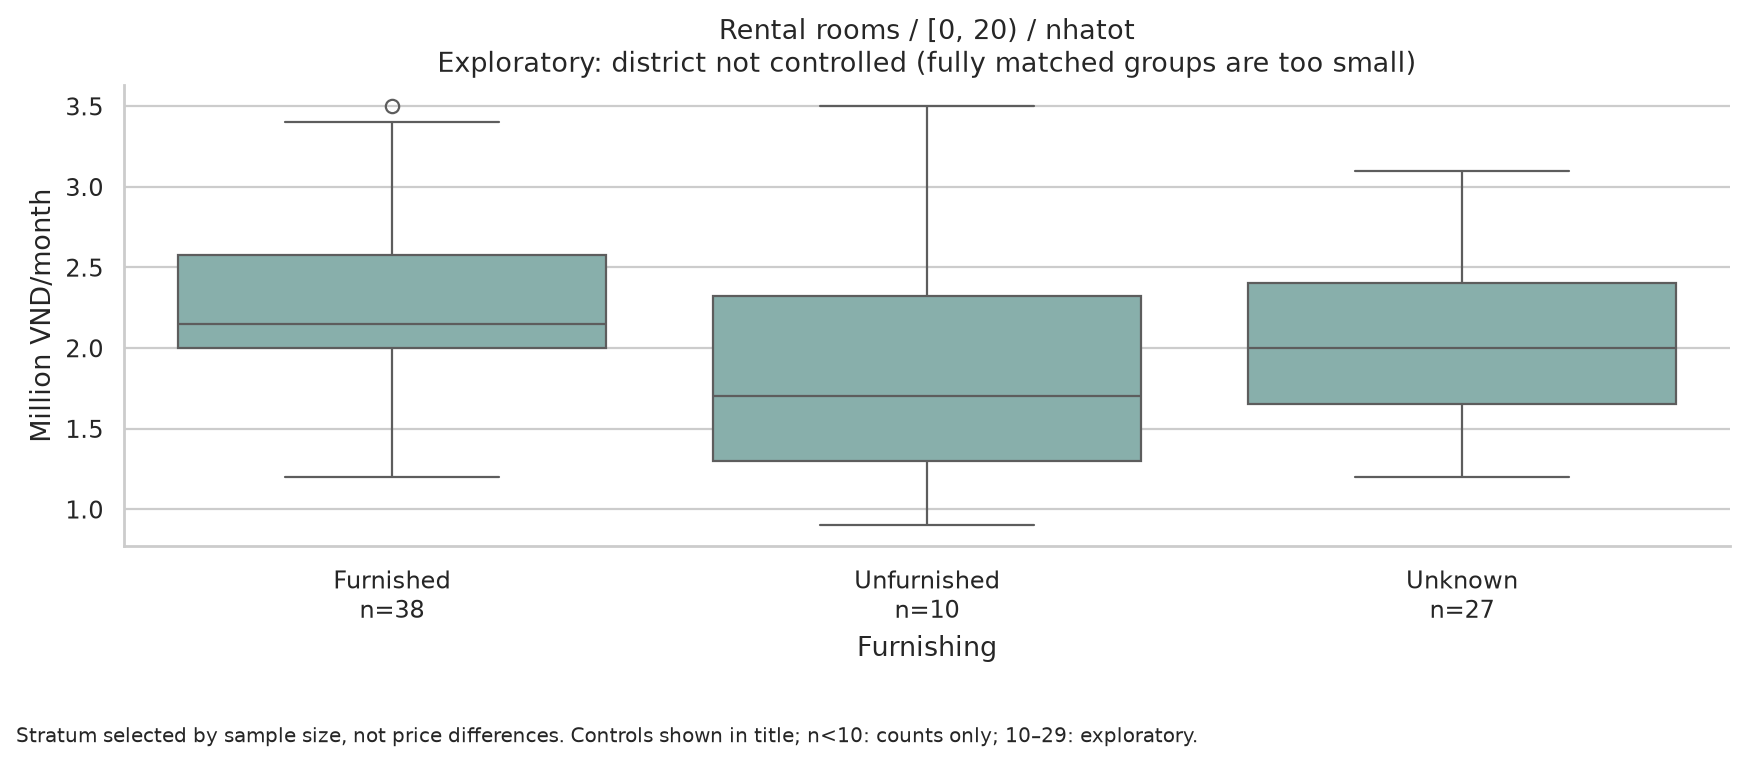

Private houses / [30, 50) / nhatot
Exploratory: district not controlled (fully matched groups are too small)


,bedroom_group,n,median,q1,q3,p90
0,1,1,12.50,12.50,12.500,12.5
1,2,18,7.25,6.25,9.375,11.0
2,3,38,10.75,10.00,13.875,15.3
3,4+,29,13.00,11.00,15.000,18.4
4,Unknown,7,11.00,7.40,13.500,16.8


Rental rooms / [0, 20) / nhatot
Exploratory: district not controlled (fully matched groups are too small)


,furniture_analysis,n,median,q1,q3,p90
0,Furnished,38,2.15,2.00,2.575,3.06
1,Unfurnished,10,1.70,1.30,2.325,2.69
2,Unknown,27,2.00,1.65,2.400,2.94


In [6]:
show_figure(7)
show_figure(8)
show_figure(9)
for feature, nt_only in [("bedroom_group", False), ("furniture_analysis", True)]:
    selected, label = select_controlled(price, feature, nt_only)
    print(label)
    display(summarize(selected, [feature]))

## 5. Source comparison — a central question

Match category × district × area_band. Require ≥10 listings per source for exploratory comparisons; ≥30 per source for the main comparison tier. Location, furnishing, continuous area and posting practices are not fully controlled. Do not interpret differences as causal website effects.

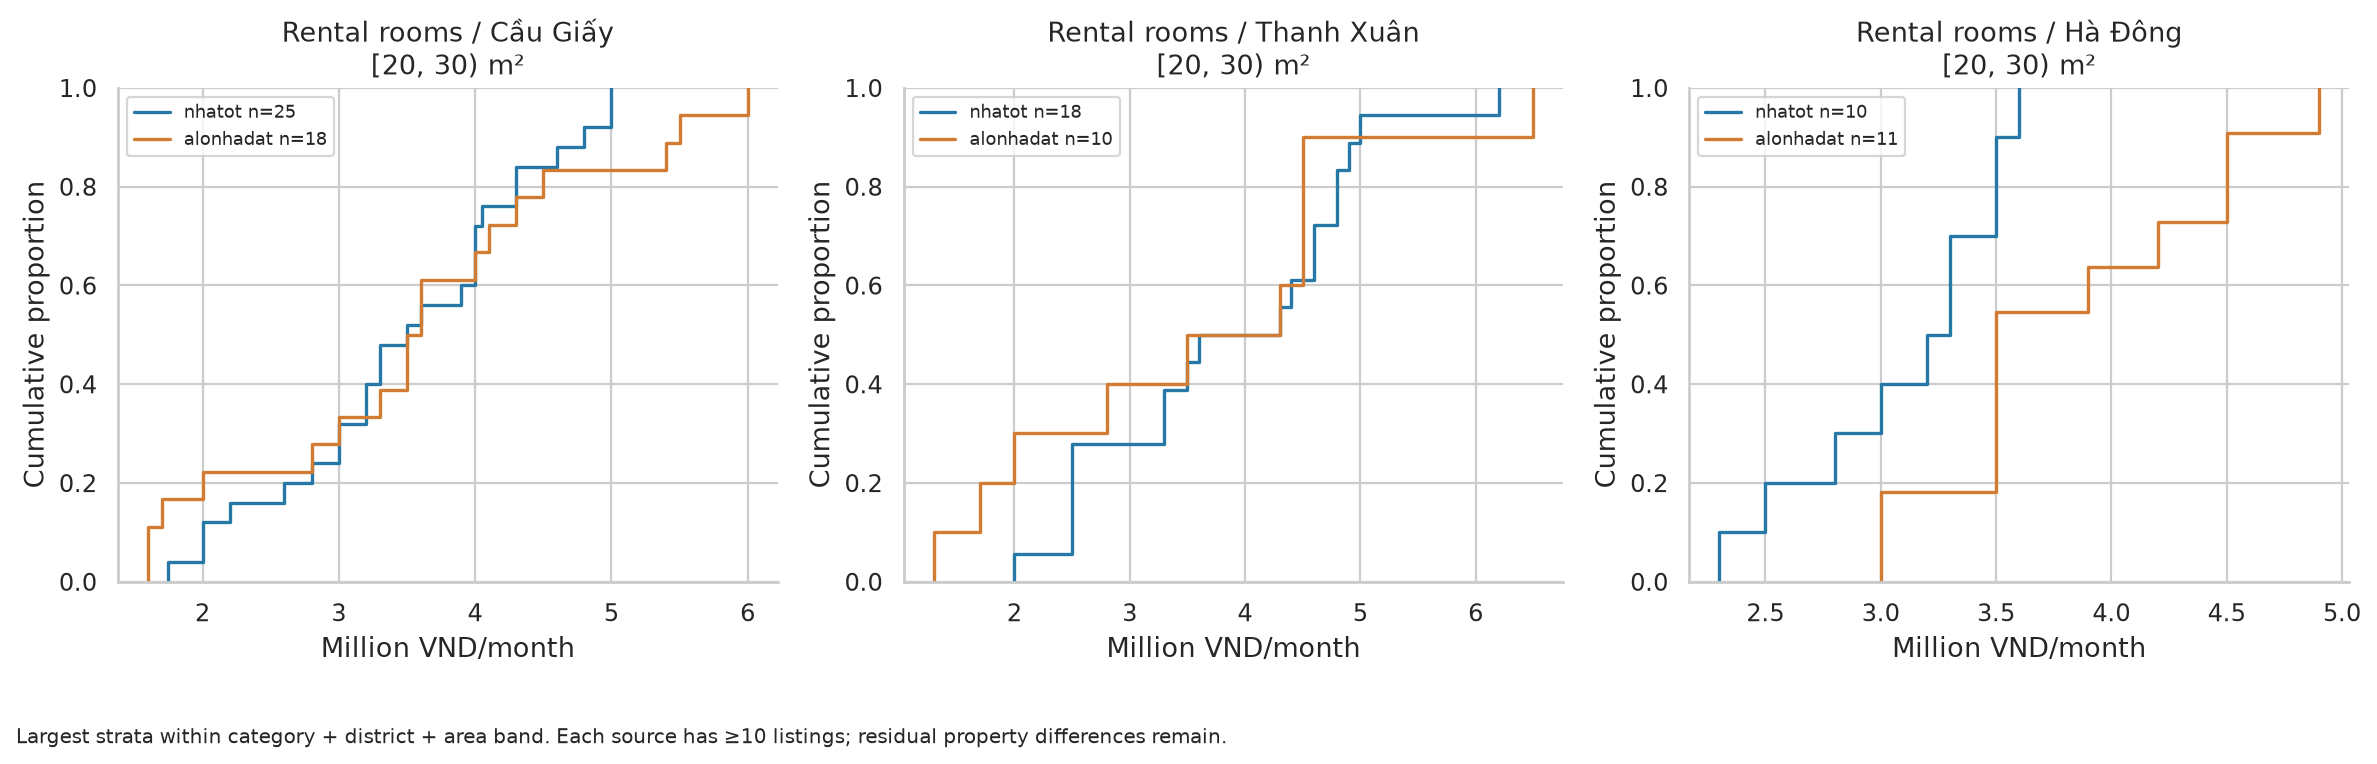

source,category,district_analysis,area_band,nhatot,alonhadat,both_sources,eligible,main,n_total
135,nha_tro,Cầu Giấy,"[20, 30)",25,18,True,True,False,43
100,nha_rieng,Long Biên,"[30, 50)",4,38,True,False,False,42
164,nha_tro,Nam Từ Liêm,"[20, 30)",33,7,True,False,False,40
150,nha_tro,Hoàng Mai,"[20, 30)",32,3,True,False,False,35
173,nha_tro,Thanh Xuân,"[20, 30)",18,10,True,True,False,28
...,...,...,...,...,...,...,...,...,...
146,nha_tro,Hoàn Kiếm,"[0, 20)",1,1,True,False,False,2
162,nha_tro,Long Biên,"[60, inf)",1,1,True,False,False,2
142,nha_tro,Hai Bà Trưng,"[60, inf)",1,1,True,False,False,2
144,nha_tro,Hoài Đức,"[30, 40)",1,1,True,False,False,2


,category,district_analysis,area_band,source,n,median,q1,q3,p90
0,nha_tro,Cầu Giấy,"[20, 30)",alonhadat,18,3.55,2.85,4.25,5.43
1,nha_tro,Cầu Giấy,"[20, 30)",nhatot,25,3.50,3.00,4.05,4.72
2,nha_tro,Hà Đông,"[20, 30)",alonhadat,11,3.50,3.50,4.35,4.50
3,nha_tro,Hà Đông,"[20, 30)",nhatot,10,3.25,2.85,3.45,3.51
4,nha_tro,Thanh Xuân,"[20, 30)",alonhadat,10,3.90,2.20,4.50,4.70
5,nha_tro,Thanh Xuân,"[20, 30)",nhatot,18,3.95,2.70,4.75,4.93


Matched groups with ≥10 per source: 3 stratum, 92/1846 listings. ≥30 per source: 0 stratum.


In [7]:
show_figure(10)
strata, source_stats, matched = source_comparison(price)
display(strata[strata.both_sources].sort_values("n_total", ascending=False))
display(source_stats)
print(f"Matched groups with ≥10 per source: {strata.eligible.sum()} stratum, {len(matched)}/{len(price)} listings. ≥30 per source: {strata.main.sum()} stratum.")

## 6. Sensitivity analysis

Change one decision at a time: add unresolved-scope listings with valid prices; keep one representative per candidate duplicate group; trim category-specific P1/P99 tails; separate sources. Do not reintroduce confirmed price errors or excluded commercial listings. These trimming scenarios must not be used to improve test-set model scores.

In [8]:
sensitivity, thresholds, district_sensitivity, scenarios = sensitivity_sets(analysis)
display(sensitivity)
display(thresholds)
display(district_sensitivity[district_sensitivity.n.ge(30)])

,scenario,category,n,median,q1,q3,area_pairs,spearman,median_change_pct
0,base,can_ho_chung_cu,541,9.80,6.500,14.000,527,0.855813,0.000000
1,base,nha_rieng,322,11.75,8.500,17.000,311,0.513170,0.000000
2,base,nha_tro,983,4.00,3.000,5.000,613,0.676231,0.000000
3,plus_pending_scope,can_ho_chung_cu,543,9.80,6.500,13.750,529,0.855858,0.000000
4,plus_pending_scope,nha_rieng,369,12.00,9.000,23.000,358,0.620007,2.127660
5,plus_pending_scope,nha_tro,987,4.00,3.000,5.000,615,0.677236,0.000000
6,one_per_candidate_group,can_ho_chung_cu,538,10.00,6.500,14.000,525,0.855445,2.040816
7,one_per_candidate_group,nha_rieng,318,11.25,8.500,16.875,307,0.503430,-4.255319
8,one_per_candidate_group,nha_tro,978,4.00,3.000,5.000,610,0.676608,0.000000
9,trim_p01_p99,can_ho_chung_cu,532,9.50,6.500,13.500,518,0.857820,-3.061224


,category,p01_vnd,p99_vnd,removed
0,can_ho_chung_cu,3200000.0,27600000.0,9
1,nha_rieng,3605000.0,200000000.0,7
2,nha_tro,1200000.0,10500000.0,11


,category,district_analysis,n,median,q1,q3,p90,scenario
0,can_ho_chung_cu,Ba Đình,48,10.0,7.50,18.250,22.30,base
2,can_ho_chung_cu,Cầu Giấy,91,13.0,8.65,15.500,21.00,base
4,can_ho_chung_cu,Hai Bà Trưng,31,7.0,5.30,12.000,13.00,base
7,can_ho_chung_cu,Hoàng Mai,33,7.0,5.20,8.500,11.90,base
9,can_ho_chung_cu,Long Biên,33,6.0,5.00,10.000,10.80,base
...,...,...,...,...,...,...,...,...
253,can_ho_chung_cu,Nam Từ Liêm,39,13.0,11.00,15.000,18.00,alonhadat_only
255,can_ho_chung_cu,Thanh Xuân,45,14.0,13.00,17.000,18.60,alonhadat_only
265,nha_rieng,Long Biên,53,9.0,8.00,10.000,12.90,alonhadat_only
272,nha_tro,Bắc Từ Liêm,30,3.5,2.90,4.475,7.00,alonhadat_only


## 7. Modeling readiness — no model training

Proposed target: monthly asking rent; consider a log target through validation. Core features: category, district and area; bedrooms/furnishing depend on coverage; exclude bathrooms from the initial baseline. Use source for diagnostics and ablation.

Exclude target copies/transformations, price-bearing titles, URL/ID and price-dependent review flags from predictors. Fit imputation on training data only. Split by candidate duplicate group with seed 42; the table checks an approximate 80/20 group split, not an untouched holdout.

Future baseline: training median by category, falling back to the overall training median. Primary metric: MAE in VND/month; secondary: RMSE, plus source/category breakdowns. Prefer an unseen snapshot for final evaluation.

In [9]:
coverage = feature_coverage(price)
display(coverage[coverage.group.eq("ALL")])
display(coverage.pivot(index="group", columns="feature", values="coverage_pct").round(1))
display(proposed_split_coverage(price))

,group,feature,n,available,coverage_pct
0,ALL,category,1846,1846,100.000000
1,ALL,district_analysis,1846,1846,100.000000
2,ALL,area_analysis_m2,1846,1451,78.602384
3,ALL,bedrooms_analysis,1846,915,49.566631
4,ALL,toilets_analysis,1846,443,23.997833
5,ALL,furniture,1846,1143,61.917660
6,ALL,source,1846,1846,100.000000


feature,area_analysis_m2,bedrooms_analysis,category,district_analysis,furniture,source,toilets_analysis
group,,,,,,,
ALL,78.6,49.6,100.0,100.0,61.9,100.0,24.0
alonhadat/can_ho_chung_cu,100.0,100.0,100.0,100.0,31.7,100.0,35.2
alonhadat/nha_rieng,99.3,87.1,100.0,100.0,29.5,100.0,12.2
alonhadat/nha_tro,100.0,46.6,100.0,100.0,56.8,100.0,1.9
nhatot/can_ho_chung_cu,95.5,97.1,100.0,100.0,62.1,100.0,71.7
nhatot/nha_rieng,94.5,90.7,100.0,100.0,23.5,100.0,63.9
nhatot/nha_tro,52.4,0.0,100.0,100.0,86.9,100.0,0.0


,proposed_partition,source,category,n,groups
0,test_candidate,alonhadat,can_ho_chung_cu,44,44
1,test_candidate,alonhadat,nha_rieng,22,21
2,test_candidate,alonhadat,nha_tro,45,44
3,test_candidate,nhatot,can_ho_chung_cu,78,78
4,test_candidate,nhatot,nha_rieng,28,28
5,test_candidate,nhatot,nha_tro,153,152
6,train_candidate,alonhadat,can_ho_chung_cu,183,183
7,train_candidate,alonhadat,nha_rieng,117,114
8,train_candidate,alonhadat,nha_tro,161,159
9,train_candidate,nhatot,can_ho_chung_cu,236,233


## 8. Export the report and read the findings

In [10]:
report_path = write_report(analysis, figures, ROOT)
report = report_path.read_text(encoding="utf-8")
insights = report.split("## 2. Key findings", 1)[1].split("## 3.", 1)[0]
display(Markdown(insights))
print("Report:", report_path)
print("10 figures:", ROOT / "reports/figures")



**1. Sample composition differs between sources.** Rental rooms account for 61.3% of Nhatot listings and 31.5% of Alonhadat listings. An aggregate price comparison cannot separate this composition difference. See Figure 01.

**2. Area availability differs between sources.** Original area missingness is 30.6% on Nhatot and 0.0% on Alonhadat. The primary price/m² set contains 1,140 listings and excludes private houses; it does not represent the entire price set. See Figure 02 and the area-availability comparison below.

**3. Asking rents differ by property type.** Apartments: 9.80 million VND/month, Q1–Q3 6.50–14.00, n=541; Private houses: 11.75 million VND/month, Q1–Q3 8.50–17.00, n=322; Rental rooms: 4.00 million VND/month, Q1–Q3 3.00–5.00, n=983. These are asking rents in the filtered sample, not transaction prices. See Figure 03.

| category | n | median | q1 | q3 | p90 |
| --- | --- | --- | --- | --- | --- |
| Apartments | 541 | 9.80 | 6.50 | 14.00 | 18.00 |
| Private houses | 322 | 11.75 | 8.50 | 17.00 | 38.00 |
| Rental rooms | 983 | 4.00 | 3.00 | 5.00 | 6.50 |

**4. District comparisons should stay within the same property type.** The two largest apartment groups meeting n≥30 are shown below, selected by sample size rather than price. Read median differences alongside Q1–Q3. Area and source composition still differ, so the gap cannot be attributed to location alone. This is not a market-wide ranking. See Figure 05.

| district_analysis | n | median | q1 | q3 | p90 |
| --- | --- | --- | --- | --- | --- |
| Cầu Giấy | 91 | 13.00 | 8.65 | 15.50 | 21.00 |
| Nam Từ Liêm | 83 | 10.00 | 6.30 | 13.50 | 16.00 |

**5. The area–price relationship depends on property type.** The table uses valid price/area pairs; missing area may bias the subset. Private-house results remain exploratory because land area and floor area can differ. See Figure 07.

| category | area_pairs | spearman |
| --- | --- | --- |
| Apartments | 527 | 0.86 |
| Private houses | 311 | 0.51 |
| Rental rooms | 613 | 0.68 |

**6. Matched source comparisons have limited coverage.** There are 188 strata with usable area and district, 111 with both sources, 3 with ≥10 listings per source, and 0 with ≥30 per source. The ≥10 groups cover 92/1846 listings in the price set; the remainder are outside this comparison. See Figure 10.

Largest matched group, selected by n: **Rental rooms / Cầu Giấy / [20, 30) m²**. The Nhatot median differs from Alonhadat by -1.4%. This is a source-associated difference after partial matching. Furnishing, location and posting practices may still differ; it is not a causal website effect.

| category | district_analysis | area_band | source | n | median | q1 | q3 | p90 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Rental rooms | Cầu Giấy | [20, 30) | alonhadat | 18 | 3.55 | 2.85 | 4.25 | 5.43 |
| Rental rooms | Cầu Giấy | [20, 30) | nhatot | 25 | 3.50 | 3.00 | 4.05 | 4.72 |

**7. Furnishing comparisons require overlapping groups.** Stratum: Rental rooms / [0, 20) / nhatot
Exploratory: district not controlled (fully matched groups are too small), n=75. Unknown is kept separate; property quality is not fully controlled. See Figure 09.

| furniture_analysis | n | median | q1 | q3 | p90 |
| --- | --- | --- | --- | --- | --- |
| Furnished | 38 | 2.15 | 2.00 | 2.58 | 3.06 |
| Unfurnished | 10 | 1.70 | 1.30 | 2.33 | 2.69 |
| Unknown | 27 | 2.00 | 1.65 | 2.40 | 2.94 |

**8. Stability depends on sample-selection decisions.** Across adding unresolved-scope listings, keeping one listing per candidate duplicate group, and trimming P1/P99, the largest absolute change in a category median is 4.3%. Details follow. Stable medians do not guarantee stable distributions or district-level findings.



Report: /home/gyga/Project/Personal/DataScience/hanoi-rental-market-analysis/reports/eda_report.md
10 figures: /home/gyga/Project/Personal/DataScience/hanoi-rental-market-analysis/reports/figures
